# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2381 Ахметгареев Карим Ильгизович и Самулевич Степан Александрович. Вариант №1.

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

Генеральная совокупность — это все множество объектов, подлежащих изучению, обладающих общими признаками.

Выборка — часть генеральной совокупности, отобранная случайным образом для проведения исследования.

Ранжированный ряд — это последовательность элементов выборки, расположенных в порядке возрастания.

Вариационный ряд — это дискретный ряд, состоящий из перечня различных значений признака и соответствующих им частот.

Интервальный ряд — это ряд, в котором значения признака заданы в виде интервалов. Оптимальное количество интервалов $k$ часто рассчитывается по формуле Стерджеса:

$k = 1 + \lfloor 1.44 \ln(n) \rfloor \approx 1 + \lfloor 3.322 \lg(n) \rfloor$

Ширина интервала $h$ определяется как:
$h = \frac{x_{max} - x_{min}}{k}$

Эмпирическая функция распределения $F^*(x)$ определяет для каждого значения $x$ относительную частоту события $X < x$.


## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

### Задание 1
Для выполнения работы выбран язык программирования Python и его библиотеки pandas, numpy, matplotlib и seaborn. Выбор обусловлен широким инструментарием для статистического анализа и удобством визуализации данных в среде Jupyter.

### Задание 2
В качестве генеральной совокупности используются данные, предложенные преподавателем с сайта [se.moevm.info](https://se.moevm.info/lib/exe/fetch.php/courses:statistical_methods_of_experimental_data_handling:sample.zip). 

### Задание 3
И генеральной совокупности была сформирована выборка объёмом в 112 наблюдений. Выборка сформирована из 112 первых строк выбранного дадасета. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('sample.csv', comment='#')
data = df['nu'].values
n = len(data)

print(f"Объем выборки n: {n}")

Объем выборки n: 112


### Задание 4


In [ ]:
# --- 1. Ранжированный ряд ---
ranked_data = np.sort(data)
print(f"\nМинимальное значение: {ranked_data.min()}, Максимальное значение: {ranked_data.max()}")

# --- 2. Вариационный ряд ---
unique_vals, counts = np.unique(ranked_data, return_counts=True)
var_series = pd.DataFrame({'Значение (x_i)': unique_vals, 'Частота (m_i)': counts})

# --- 3. Интервальный ряд ---
k = int(np.ceil(1 + np.log2(n))) 
x_min, x_max = ranked_data.min(), ranked_data.max()
h = (x_max - x_min) / k

print(f"\nКоличество интервалов (k): {k}")
print(f"Шаг интервала (h): {h:.2f}")

# Интервалы
bins = np.linspace(x_min, x_max, k+1)
m_i, _ = np.histogram(ranked_data, bins=bins)


intervals = [f"[{bins[i]:.2f}, {bins[i+1]:.2f})" for i in range(k)]
x_tilde = (bins[:-1] + bins[1:]) / 2    # середины интервалов
tilda_m_i = m_i / n                     # относительные частоты
m_nak = np.cumsum(m_i)                  # накопленные абсолютные частоты
rel_m_nak = np.cumsum(tilda_m_i)        # накопленные относительные частоты

# Таблицa 1
table1 = pd.DataFrame({
    'i': range(1, k+1),
    '[x_i, x_{i+1})': intervals,
    'x_tilde_i': np.round(x_tilde, 2),
    'm_i': m_i,
    'tilda_m_i': np.round(tilda_m_i, 4),
    'm_nak_i': m_nak,
    'tilda_m_nak_i': np.round(rel_m_nak, 4)
})


sum_row = pd.DataFrame({
    'i': ['Σ'],
    '[x_i, x_{i+1})': ['-'],
    'x_tilde_i': ['-'],
    'm_i': [table1['m_i'].sum()],
    'tilda_m_i': [table1['tilda_m_i'].sum()],
    'm_nak_i': ['-'],
    'tilda_m_nak_i': ['-']
})
table1 = pd.concat([table1, sum_row], ignore_index=True)

display(table1)


Минимальное значение: 320, Максимальное значение: 593

Количество интервалов (k): 8
Шаг интервала (h): 34.12


,i,"[x_i, x_{i+1})",x_tilde_i,m_i,tilda_m_i,m_nak_i,tilda_m_nak_i
0,1,"[320.00, 354.12)",337.06,9,0.0804,9,0.0804
1,2,"[354.12, 388.25)",371.19,4,0.0357,13,0.1161
2,3,"[388.25, 422.38)",405.31,25,0.2232,38,0.3393
3,4,"[422.38, 456.50)",439.44,23,0.2054,61,0.5446
4,5,"[456.50, 490.62)",473.56,24,0.2143,85,0.7589
5,6,"[490.62, 524.75)",507.69,16,0.1429,101,0.9018
6,7,"[524.75, 558.88)",541.81,7,0.0625,108,0.9643
7,8,"[558.88, 593.00)",575.94,4,0.0357,112,1.0
8,Σ,-,-,112,1.0001,-,-


Полученная таблица демонстрирует группировку данных. Наибольшая концентрация значений объемного веса древесины (модальный интервал) находится примерно в середине распределения, что характерно для величин, имеющих распределение, близкое к нормальному.

### Задание 5


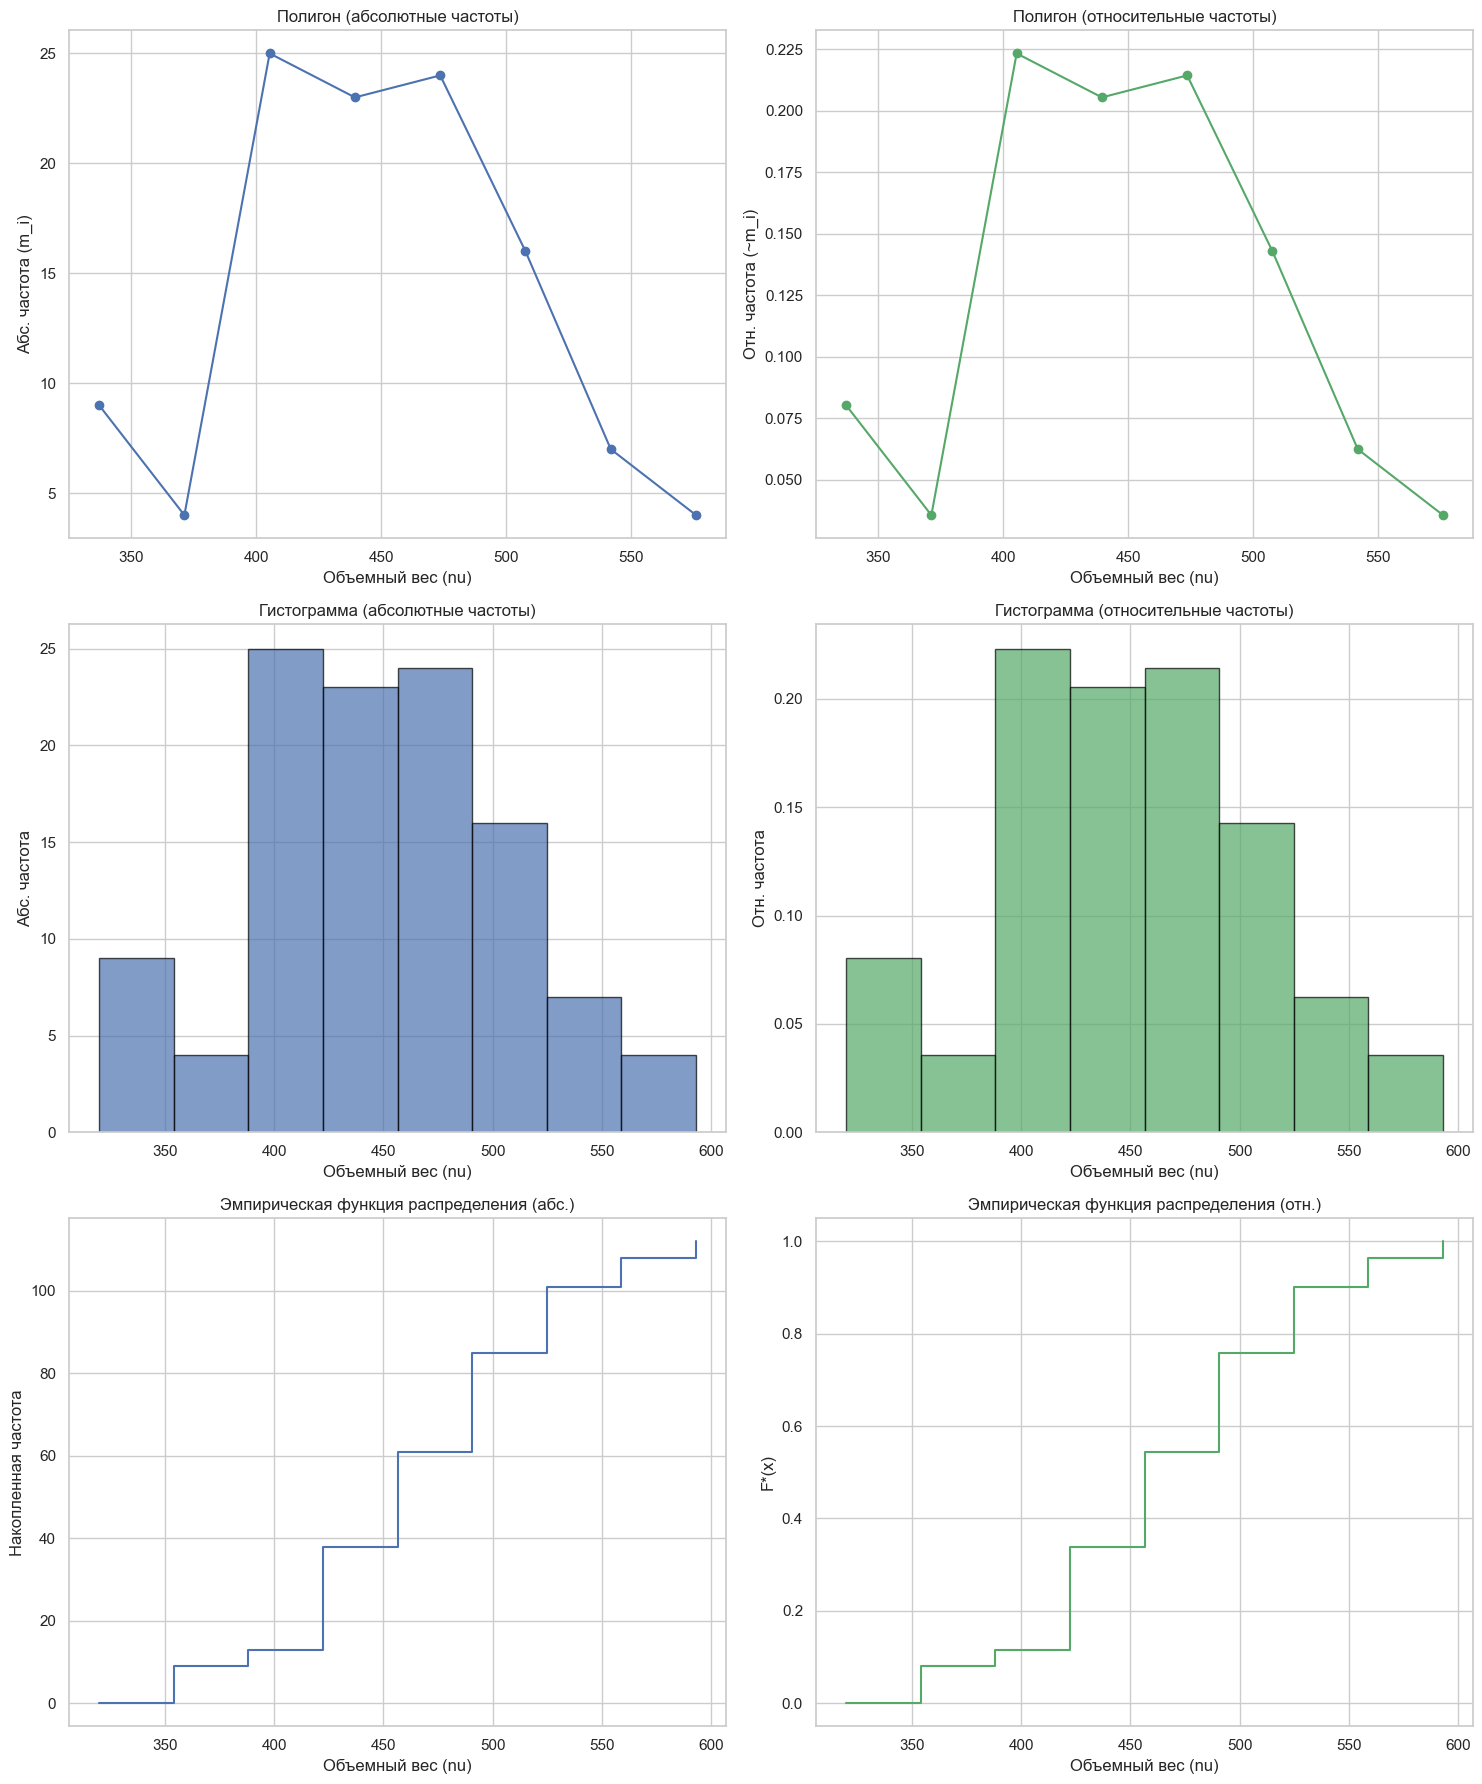

In [16]:

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
x_poly = x_tilde


axes[0, 0].plot(x_poly, m_i, marker='o', linestyle='-', color='b')
axes[0, 0].set_title('Полигон (абсолютные частоты)')
axes[0, 0].set_xlabel('Объемный вес (nu)')
axes[0, 0].set_ylabel('Абс. частота (m_i)')


axes[0, 1].plot(x_poly, tilda_m_i, marker='o', linestyle='-', color='g')
axes[0, 1].set_title('Полигон (относительные частоты)')
axes[0, 1].set_xlabel('Объемный вес (nu)')
axes[0, 1].set_ylabel('Отн. частота (~m_i)')


axes[1, 0].hist(ranked_data, bins=bins, edgecolor='black', alpha=0.7, color='b')
axes[1, 0].set_title('Гистограмма (абсолютные частоты)')
axes[1, 0].set_xlabel('Объемный вес (nu)')
axes[1, 0].set_ylabel('Абс. частота')


axes[1, 1].hist(ranked_data, bins=bins, weights=np.ones(n)/n, edgecolor='black', alpha=0.7, color='g')
axes[1, 1].set_title('Гистограмма (относительные частоты)')
axes[1, 1].set_xlabel('Объемный вес (nu)')
axes[1, 1].set_ylabel('Отн. частота')


axes[2, 0].step(np.concatenate(([bins[0]], bins[1:])), np.concatenate(([0], m_nak)), where='post', color='b')
axes[2, 0].set_title('Эмпирическая функция распределения (абс.)')
axes[2, 0].set_xlabel('Объемный вес (nu)')
axes[2, 0].set_ylabel('Накопленная частота')


axes[2, 1].step(np.concatenate(([bins[0]], bins[1:])), np.concatenate(([0], rel_m_nak)), where='post', color='g')
axes[2, 1].set_title('Эмпирическая функция распределения (отн.)')
axes[2, 1].set_xlabel('Объемный вес (nu)')
axes[2, 1].set_ylabel('F*(x)')

plt.tight_layout()
plt.show()

На основе построенных графиков для абсолютных частот можно сделать следующие выводы:

Полигон и гистограмма: Оба графика наглядно показывают распределение плотности данных выборки. Пик гистограммы и полигона приходится на центральные интервалы (в районе значений 420–480 г/см³), что указывает на то, что большинство образцов древесины имеют средний объемный вес. Резкие перепады высот отсутствуют, что говорит о непрерывном характере изменения признака.

Эмпирическая функция распределения (ЭФР): График представляет собой ступенчатую неубывающую функцию. Высота последней ступени в точке $x_{max}$ в точности равна объему выборки $n = 112$. Крутизна графика в центре подтверждает высокую концентрацию данных в среднем диапазоне.

При анализе графиков относительных частот и их сравнении с результатами пункта 5 выявлено следующее:

Геометрическая форма полигона, гистограммы и ЭФР для относительных частот полностью идентична форме графиков для абсолютных частот. Это объясняется тем, что относительная частота $\tilde{m}_i$ — это нормированная величина, полученная делением абсолютной частоты $m_i$ на постоянное число $n$ (объем выборки).

Основное различие заключается в масштабе оси ординат. Для относительных частот значения лежат в диапазоне $[0, 1]$. Сумма площадей всех столбцов гистограммы относительных частот равна 1, что соответствует полной вероятности.

Эмпирическая функция для относительных частот $F^*(x)$ удобнее для статистического анализа, так как она позволяет оценить вероятность того, что случайная величина примет значение меньше заданного $x$. В точке $x_{max}$ функция достигает значения 1.0.

## Выводы




В ходе выполнения практической работы была успешно сформирована выборка объемного веса древесины из 112 наблюдений. Исходные данные были преобразованы в ранжированный, вариационный и интервальный ряды.
Анализ построенных полигонов и гистограмм для абсолютных и относительных частот показывает, что их формы визуально идентичны и отличаются лишь масштабом оси ординат. Распределение имеет колоколообразную форму с пиком в центральных интервалах, что свидетельствует о его близости к нормальному закону распределения. График эмпирической функции распределения имеет характерную неубывающую ступенчатую форму, стремящуюся к объему выборки (для абсолютных частот) и к единице (для относительных).